# Aesthetic Specifications

Ported from R vignette [`ggplot2-specs.qmd`](https://ggplot2.tidyverse.org/articles/ggplot2-specs.html).

This vignette summarises the various visual properties (aesthetics) that control
how geoms are drawn. Most of this information is available in the R documentation;
this tutorial brings it all together in one place.

In [1]:
from ggplot2_py import *
from ggplot2_py.plot import GGPlot
from ggplot2_py.datasets import mpg
import pandas as pd
import numpy as np

GGPlot.fig_width = 7
GGPlot.fig_height = 5
GGPlot.fig_dpi = 96

## Colour and fill

Almost every geom has either `colour`, `fill`, or both. Colours and fills can be specified as:

- A **name**, e.g. `"steelblue"` (matplotlib named colours)
- An **RGB hex string**, e.g. `"#RRGGBB"` or `"#RRGGBBAA"` with alpha
- `None` for a completely transparent colour

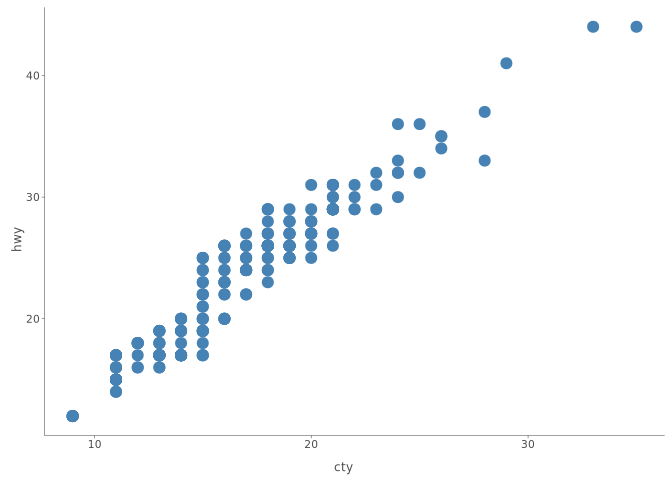

In [2]:
# Named colour
ggplot(mpg, aes('cty', 'hwy')) + geom_point(colour='steelblue', size=2)

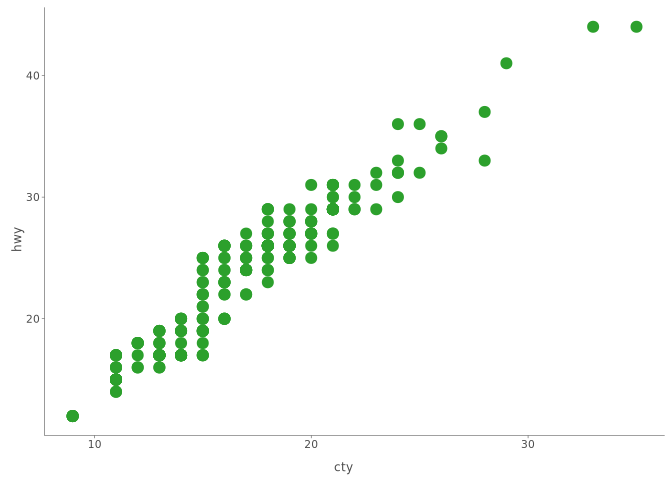

In [3]:
# Hex RGB colour
ggplot(mpg, aes('cty', 'hwy')) + geom_point(colour='#2ca02c', size=2)

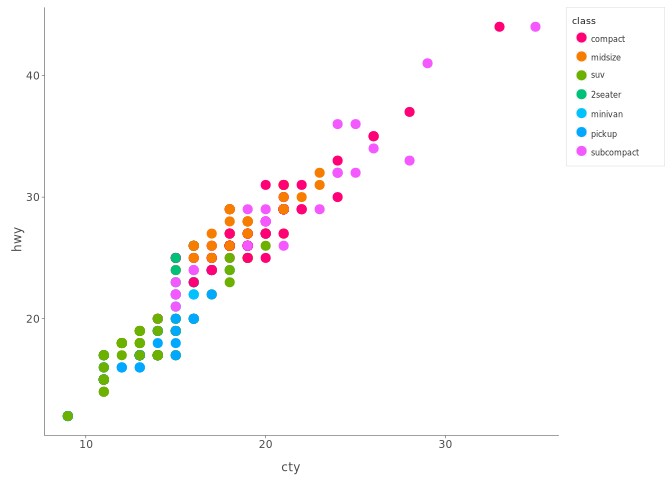

In [4]:
# Colour mapped to a categorical variable
ggplot(mpg, aes('cty', 'hwy', colour='class')) + geom_point()

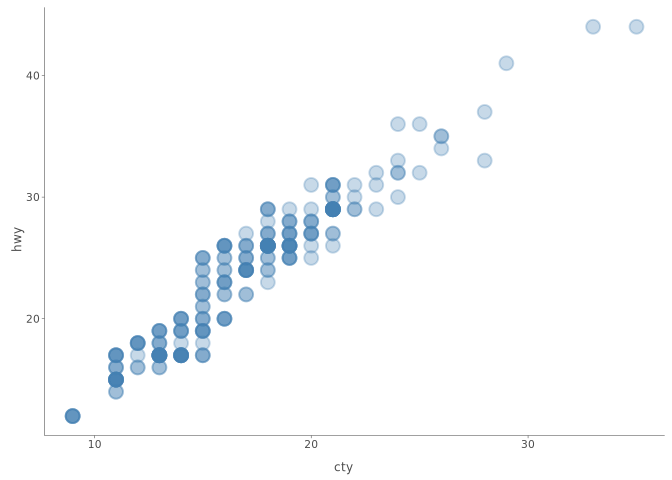

In [5]:
# Alpha transparency
ggplot(mpg, aes('cty', 'hwy')) + geom_point(colour='steelblue', alpha=0.3, size=3)

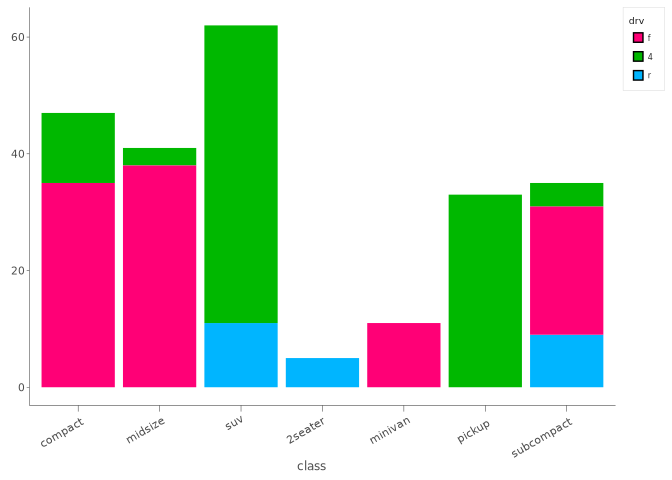

In [6]:
# Fill in bar charts
ggplot(mpg, aes(x='class', fill='drv')) + geom_bar()

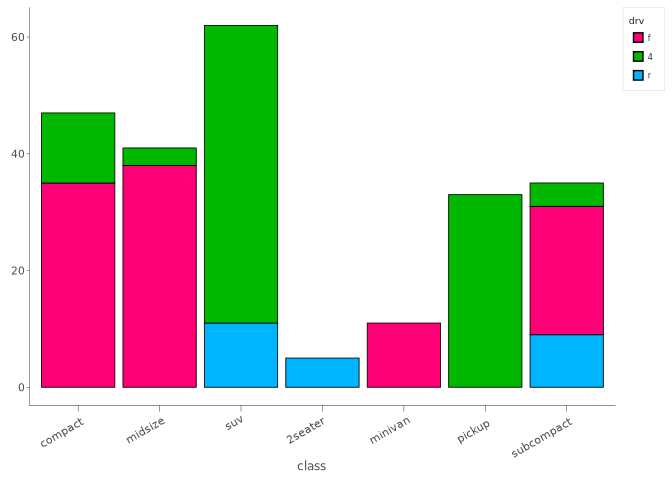

In [7]:
# Polygons: border controlled by colour, inside by fill
ggplot(mpg, aes(x='class', fill='drv')) + geom_bar(colour='black', linewidth=0.3)

## Lines

The appearance of a line is affected by `linewidth`, `linetype`, `linejoin` and `lineend`.

### Line type

Line types can be specified with an integer or name:
0 = blank, 1 = solid, 2 = dashed, 3 = dotted, 4 = dotdash, 5 = longdash, 6 = twodash.

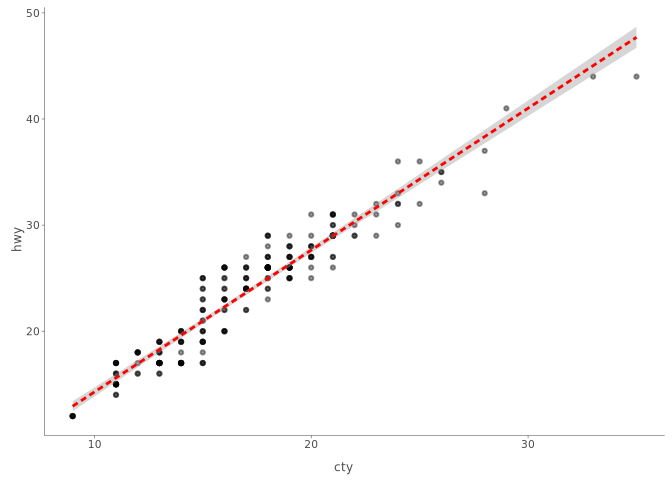

In [8]:
# Dashed trend line
(
    ggplot(mpg, aes('cty', 'hwy'))
    + geom_point(size=0.5, alpha=0.4)
    + geom_smooth(method='lm', linetype='dashed', colour='red')
)

### Linewidth

Due to a historical convention in R, the unit of linewidth is roughly 0.75 mm.

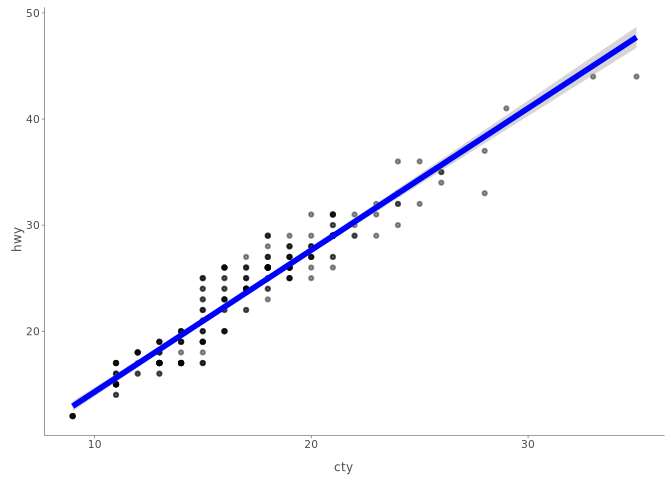

In [9]:
# Thick trend line
(
    ggplot(mpg, aes('cty', 'hwy'))
    + geom_point(size=0.5, alpha=0.4)
    + geom_smooth(method='lm', linewidth=2, colour='blue')
)

### Line end/join parameters

`lineend` can be `"round"`, `"butt"` (default), or `"square"`.
`linejoin` can be `"round"` (default), `"mitre"`, or `"bevel"`.

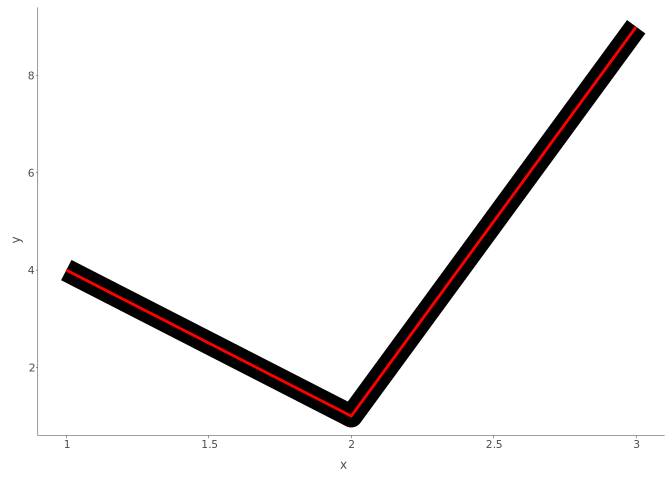

In [10]:
# Line end demonstration: thick black + thin red overlay
df = pd.DataFrame({'x': [1, 2, 3], 'y': [4, 1, 9]})
(
    ggplot(df, aes('x', 'y'))
    + geom_path(linewidth=8)
    + geom_path(linewidth=1, colour='red')
)

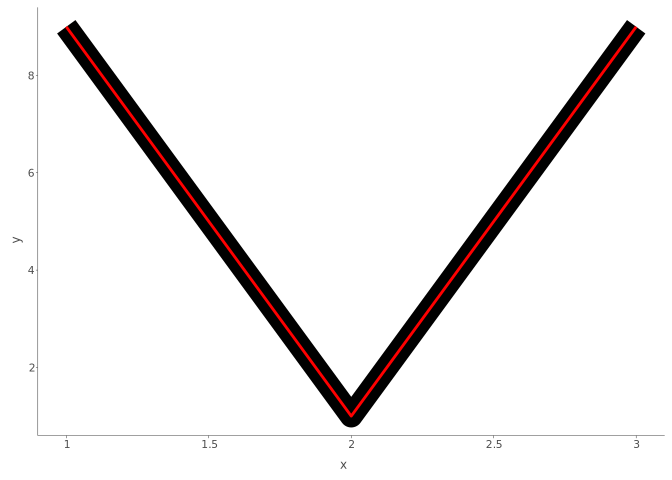

In [11]:
# Line join demonstration
df = pd.DataFrame({'x': [1, 2, 3], 'y': [9, 1, 9]})
(
    ggplot(df, aes('x', 'y'))
    + geom_path(linewidth=8)
    + geom_path(linewidth=1, colour='red')
)

## Point

### Shape

Shapes take several types of values:
- An **integer** in [0, 25]: shapes 0-14 are lines/open shapes, 15-20 are solid, 21-25 are filled
- A **variable** mapped via `aes(shape=...)`

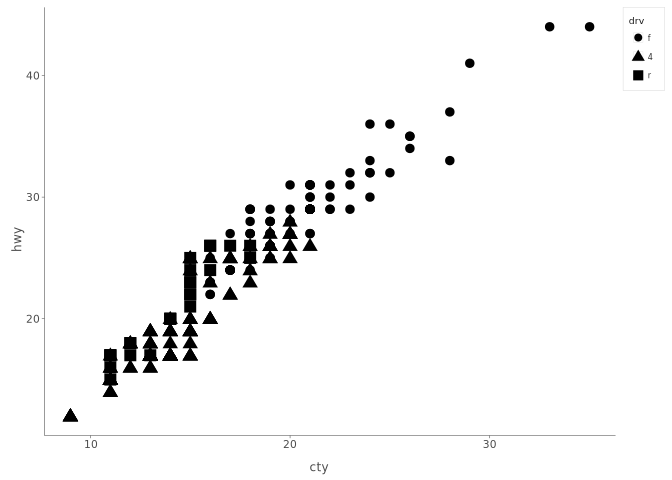

In [12]:
# Shape mapped to variable
ggplot(mpg, aes('cty', 'hwy', shape='drv')) + geom_point(size=2)

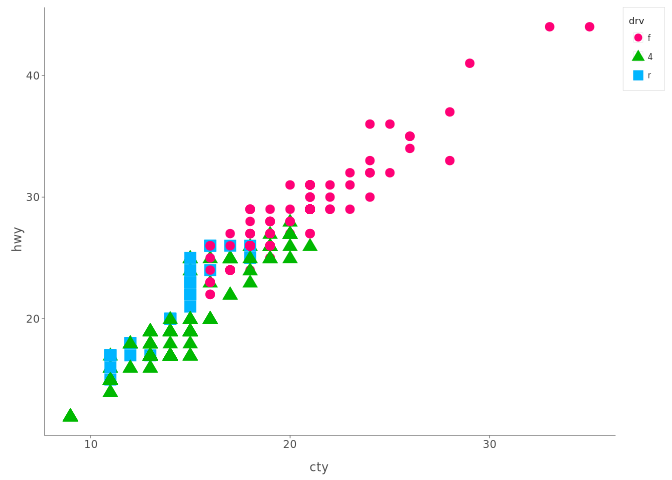

In [13]:
# Multiple aesthetics mapped: colour + shape
ggplot(mpg, aes('cty', 'hwy', colour='drv', shape='drv')) + geom_point(size=2)

### Colour, fill, size, stroke

`colour` applies to all shapes. `fill` only applies to shapes 21-25.
The size of the filled part is controlled by `size`, the outline by `stroke`.

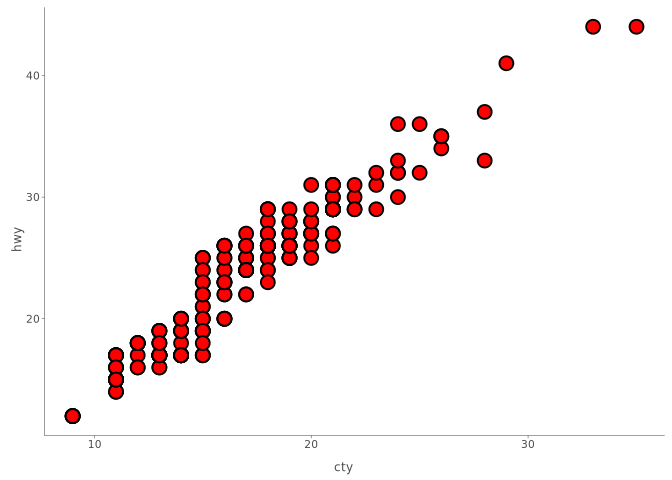

In [14]:
# Filled shape 21 (circle) with colour and fill
ggplot(mpg, aes('cty', 'hwy')) + geom_point(shape=21, colour='black', fill='red', size=3)

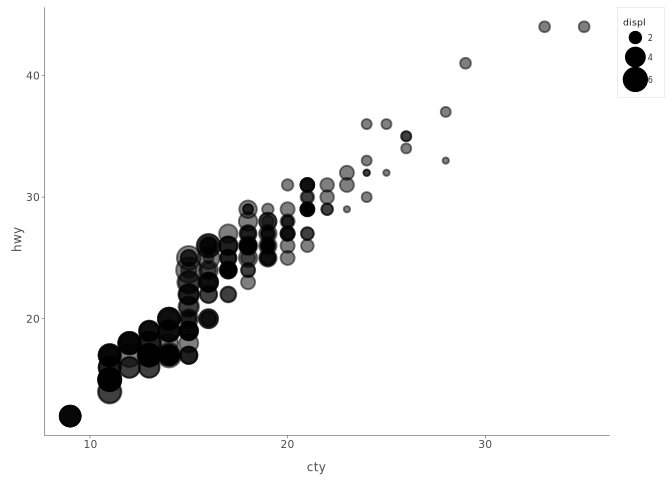

In [15]:
# Size mapped to continuous variable
ggplot(mpg, aes('cty', 'hwy', size='displ')) + geom_point(alpha=0.5)

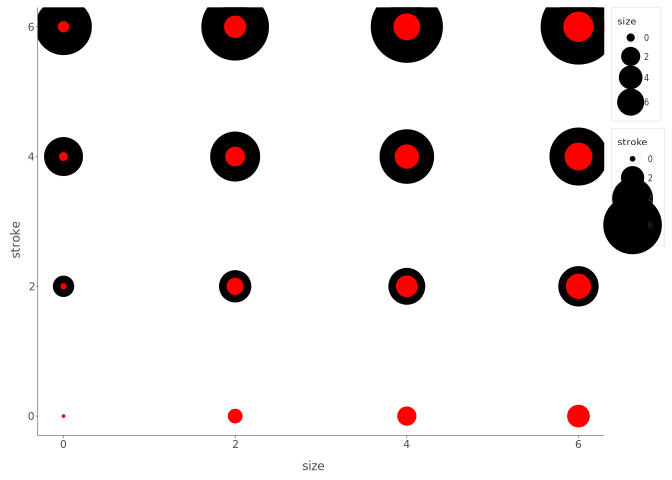

In [16]:
# Size and stroke trade-off
sizes = pd.DataFrame({
    'size': np.tile([0, 2, 4, 6], 4).astype(float),
    'stroke': np.repeat([0, 2, 4, 6], 4).astype(float),
})
ggplot(sizes, aes('size', 'stroke', size='size', stroke='stroke')) + geom_point(shape=21, fill='red')

## Text

### Font family

`family` sets the typeface: `"sans"` (default), `"serif"`, or `"mono"`.

### Font size

The `size` of text is measured in mm by default.

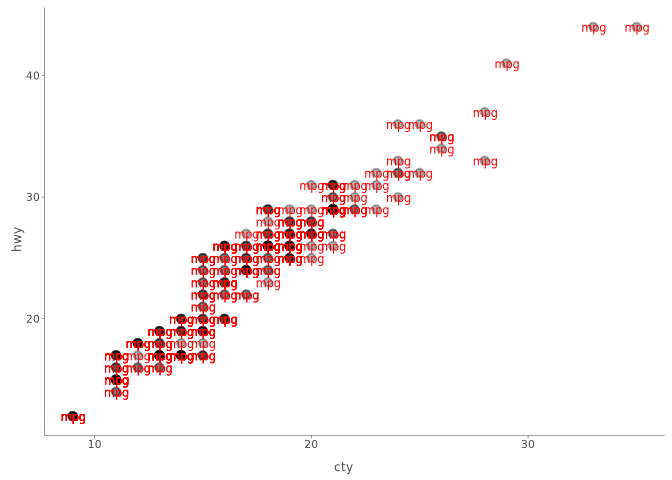

In [17]:
# Text labels at different positions
(
    ggplot(mpg, aes('cty', 'hwy'))
    + geom_point(alpha=0.3)
    + geom_text(label='mpg', size=3, colour='red')
)

## Colour Scales

Colour scales translate data values into visual colours. ggplot2_py provides
the same scale functions as R.

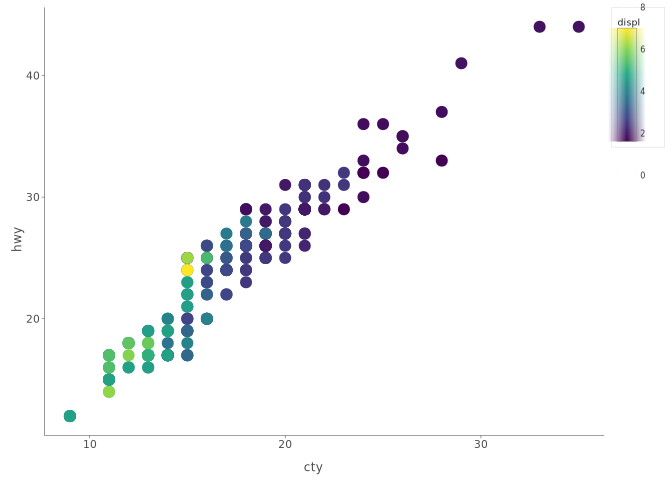

In [18]:
# Continuous: viridis
ggplot(mpg, aes('cty', 'hwy', colour='displ')) + geom_point(size=2) + scale_colour_viridis_c()

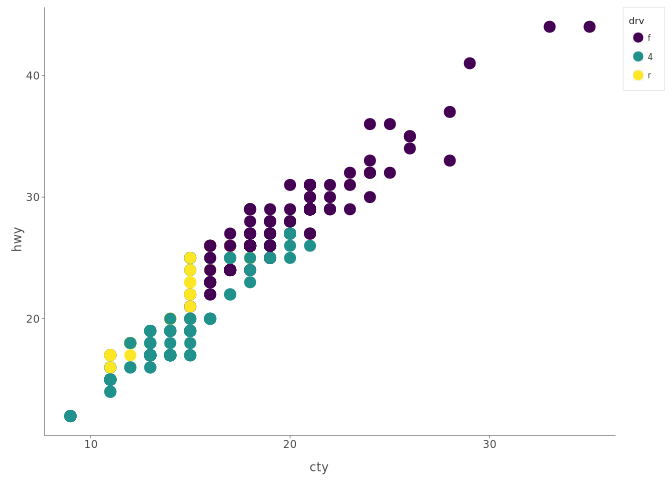

In [19]:
# Discrete: viridis
ggplot(mpg, aes('cty', 'hwy', colour='drv')) + geom_point(size=2) + scale_colour_viridis_d()

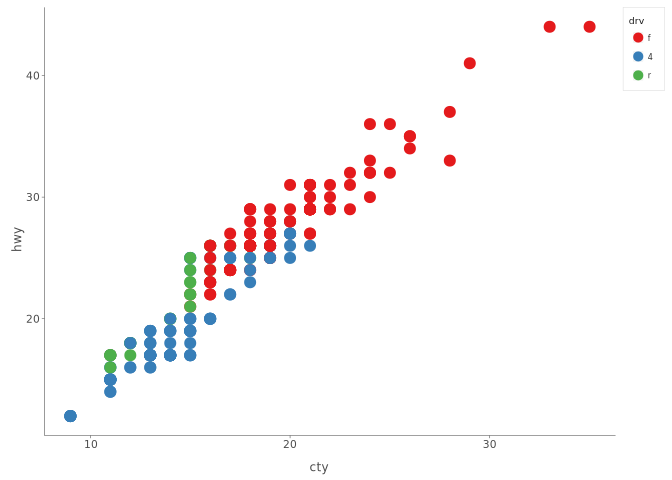

In [20]:
# Discrete: ColorBrewer Set1
ggplot(mpg, aes('cty', 'hwy', colour='drv')) + geom_point(size=2) + scale_colour_brewer(palette='Set1')

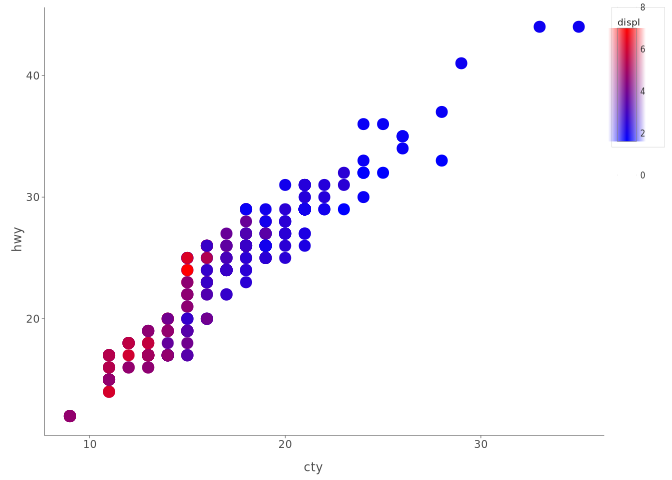

In [21]:
# Continuous gradient: blue to red
ggplot(mpg, aes('cty', 'hwy', colour='displ')) + geom_point(size=2) + scale_colour_gradient(low='blue', high='red')

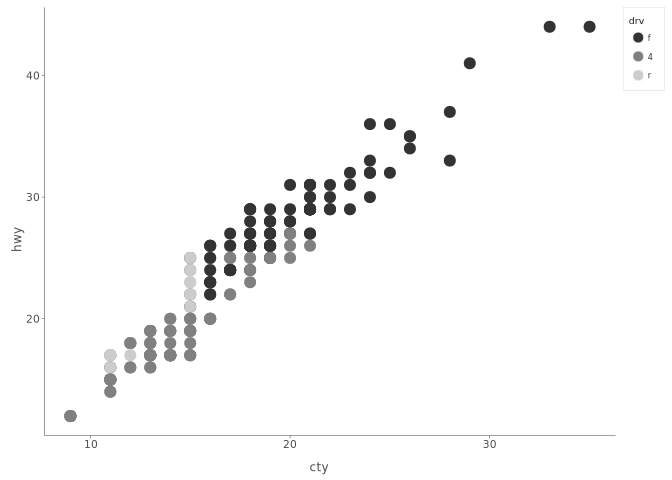

In [22]:
# Grey scale
ggplot(mpg, aes('cty', 'hwy', colour='drv')) + geom_point(size=2) + scale_colour_grey()

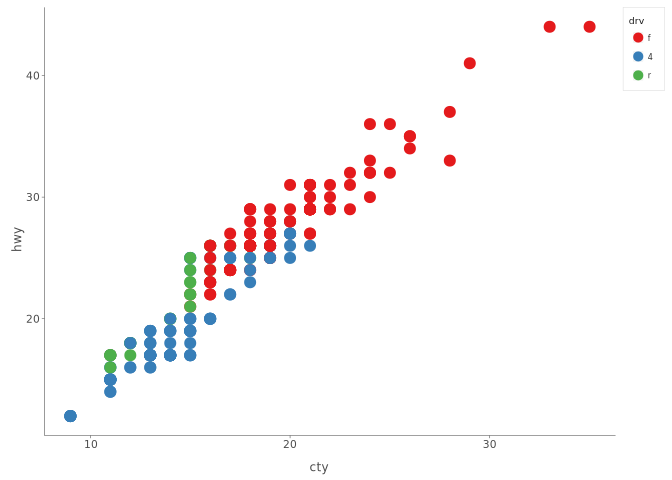

In [23]:
# Manual colours
ggplot(mpg, aes('cty', 'hwy', colour='drv')) + geom_point(size=2) + scale_colour_manual(values={'4': '#e41a1c', 'f': '#377eb8', 'r': '#4daf4a'})